In [1]:
import requests
import xml.etree.ElementTree as ET

base = "https://assets.grokipedia.com/sitemap/sitemap-{num:05d}.xml"
out = []

for i in range(1, 235):   # 00001 to 00044 inclusive
    url = base.format(num=i)
    print("Fetching:", url)
    r = requests.get(url)
    r.raise_for_status()

    # Parse XML with namespaces
    root = ET.fromstring(r.text)
    ns = {"sm": "http://www.sitemaps.org/schemas/sitemap/0.9"}

    for loc in root.findall("sm:url/sm:loc", ns):
        out.append(loc.text)

with open("../results/v0.2_edits/urls.txt", "w") as f:
    for url in out:
        f.write(url + "\n")

print(f"Saved {len(out)} URLs to ../results/v0.2_edits/urls.txt")


Fetching: https://assets.grokipedia.com/sitemap/sitemap-00001.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00002.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00003.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00004.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00005.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00006.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00007.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00008.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00009.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00010.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00011.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00012.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00013.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00014.xml
Fetching: https://assets.grokipedia.com/sitemap/sitemap-00015.xml
Fetching: 

In [2]:
from datasets import load_dataset
import os
        
hf_token = os.getenv('HF_API_TOKEN')

# Load dataset (with or without token)
if hf_token:
    dataset = load_dataset("stefan-it/grokipedia-urls", token=hf_token)
else:
    dataset = load_dataset("stefan-it/grokipedia-urls")

In [11]:
with open('../results/v0.2_scrape/diff_urls.txt', 'w') as f:
    for url in set(out).difference(set(dataset['train']['url'])):
        f.write(url + '\n')


## Analysis

From here we assume that you've run the distributed scraper and downloaded files to `../results/v0.2_scrape/`

In [ ]:
# create index of the data for fast lookup and save as a pickle (.pkl) file

import json
import pickle

def _norm(s: str) -> str:
    return " ".join((s or "").strip().lower().split())

def stream_ndjson(path):
    """Yields objects (dicts) one at a time from an .ndjson file."""
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                yield json.loads(line)

def build_title_pointer_index(path, title_field="name", norm_func=_norm):
    """
    Index file offsets of each normalized title for later recovery.
    Returns {normalized_title: file_offset}
    """
    idx = {}
    with open(path, "r", encoding="utf-8") as f:
        pos = 0
        for line in f:
            # Record position before reading this line
            line_start = pos
            
            if line.strip():
                obj = json.loads(line)
                title = obj.get(title_field, '')
                if title:
                    idx[norm_func(title)] = line_start
            
            # Update position by adding the byte length of this line
            pos += len(line.encode('utf-8'))
    
    return idx

def build_grokipedia_file_map(fname, norm_func=_norm):
    """
    Maps normalized title to (filename, offset within file) for all Grokipedia jsonl files.
    Returns {normalized_title: (filename, file_offset)}
    """
    idx = {}
    with open(fname, "r", encoding="utf-8") as f:
        pos = 0
        for line in f:
            # Record position before reading this line
            line_start = pos
            
            if line.strip():
                obj = json.loads(line)
                title = obj.get('data', {}).get('main_title', '')
                if title:
                    idx[norm_func(title)] = (fname, line_start)
            
            # Update position by adding the byte length of this line
            pos += len(line.encode('utf-8'))
    
    return idx

def get_object_at_offset(path, offset):
    with open(path, "r", encoding="utf-8") as f:
        f.seek(offset)
        line = f.readline()
        return json.loads(line)


grokipedia_jsonl = '../results/v0.2_scrape/scraped_data.jsonl'
index_pkl_path = '../results/v0.2_scrape/cached_grokipedia_idx_v0_2.pkl'

print("Building Grokipedia index...")
file_map = build_grokipedia_file_map(grokipedia_jsonl)
with open(index_pkl_path, 'wb') as fout:
    pickle.dump(file_map, fout)
print(f"Saved index ({len(file_map):,} entries) to {index_pkl_path}")


In [ ]:
# create index of the data for fast lookup and save as a pickle (.pkl) file

import json
import pickle

def _norm(s: str) -> str:
    return " ".join((s or "").strip().lower().split())

def stream_ndjson(path):
    """Yields objects (dicts) one at a time from an .ndjson file."""
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                yield json.loads(line)

def build_title_pointer_index(path, title_field="name", norm_func=_norm):
    """
    Index file offsets of each normalized title for later recovery.
    Returns {normalized_title: file_offset}
    """
    idx = {}
    with open(path, "r", encoding="utf-8") as f:
        pos = 0
        for line in f:
            # Record position before reading this line
            line_start = pos
            
            if line.strip():
                obj = json.loads(line)
                title = obj.get(title_field, '')
                if title:
                    idx[norm_func(title)] = line_start
            
            # Update position by adding the byte length of this line
            pos += len(line.encode('utf-8'))
    
    return idx

def build_grokipedia_file_map(fname, norm_func=_norm):
    """
    Maps normalized title to (filename, offset within file) for all Grokipedia jsonl files.
    Returns {normalized_title: (filename, file_offset)}
    """
    idx = {}
    with open(fname, "r", encoding="utf-8") as f:
        pos = 0
        for line in f:
            # Record position before reading this line
            line_start = pos
            
            if line.strip():
                obj = json.loads(line)
                title = obj.get('data', {}).get('main_title', '')
                if title:
                    idx[norm_func(title)] = (fname, line_start)
            
            # Update position by adding the byte length of this line
            pos += len(line.encode('utf-8'))
    
    return idx

def get_object_at_offset(path, offset):
    with open(path, "r", encoding="utf-8") as f:
        f.seek(offset)
        line = f.readline()
        return json.loads(line)


grokipedia_jsonl = '../results/v0.2_scrape/scraped_data.jsonl'
index_pkl_path = '../results/v0.2_scrape/cached_grokipedia_idx_v0_2.pkl'

print("Building Grokipedia index...")
file_map = build_grokipedia_file_map(grokipedia_jsonl)
with open(index_pkl_path, 'wb') as fout:
    pickle.dump(file_map, fout)
print(f"Saved index ({len(file_map):,} entries) to {index_pkl_path}")


Building Grokipedia index...


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10bb9ecb0>>
Traceback (most recent call last):
  File "/Users/haltriedman/code/wiki-grok-comparison/.venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 797, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


In [ ]:
import re

def split_by_license_phrase_from_paragraph(
    fname="../results/v0.2_scrape/scraped_data.jsonl",
    phrase="The content is adapted from Wikipedia, licensed under Creative Commons Attribution-ShareAlike 4.0 License",
    test_fp=None
):
    """
    Separates Grokipedia pages into two sets depending on whether the license phrase (possibly missing a space)
    occurs in the last 10 paragraphs of the 'paragraph' field of any page in each JSONL file.

    Returns:
        (set of file paths containing the phrase, set of file paths not containing the phrase)
    """

    articles_w_phrase = set()
    articles_wo_phrase = set()
    # i = 0

    if test_fp:
        with open(test_fp, "r", encoding="utf-8") as f:
            for line in f:
                found = False
                page = json.loads(line)
                data = page.get("data", None)
                article_title = data.get("main_title", None)
                paragraphs = data.get("paragraphs", None)
                if isinstance(paragraphs, list) and paragraphs:
                    for para in paragraphs:
                        if isinstance(para, str) and re.search(phrase, para):
                            found = True
                if found:
                    articles_w_phrase.add(article_title)
                else:
                    articles_wo_phrase.add(article_title)
                    
    else:
        with open(fname, "r", encoding="utf-8") as f:
            for line in f:
                # if i % 40000 == 0:
                #     print(f"Processing article {i} of ~885k")
                # i += 1
                try:
                    data = json.loads(line)
                    found = False
                    page = json.loads(line)
                    data = page.get("data", None)
                    article_title = data.get("main_title", None)
                    paragraphs = data.get("paragraphs", None)
                    if isinstance(paragraphs, list) and paragraphs:
                        for para in paragraphs:
                            if isinstance(para, str) and re.search(phrase, para):
                                found = True
                    if found:
                        articles_w_phrase.add(article_title)
                    else:
                        articles_wo_phrase.add(article_title)
                except Exception:
                    continue
    return articles_w_phrase, articles_wo_phrase

# Example usage to print summary:
w_phrase, wo_phrase = split_by_license_phrase_from_paragraph()
print(f"Files containing phrase: {len(w_phrase)}")
print(f"Files NOT containing phrase: {len(wo_phrase)}")

In [9]:
def find_reliability_shift_maximal(reliability_df, 
                                    grok_v01_idx_path='../results/overall/cached_grok_idx.pkl',
                                    grok_v02_idx_path='../results/v0.2_scrape/cached_grokipedia_idx_v0_2.pkl',
                                    wiki_idx_path='../results/overall/cached_wiki_idx.pkl',
                                    grok_v01_jsonl_path='../grokipedia_scrape.ndjson',
                                    grok_v02_jsonl_path='../results/v0.2_scrape/scraped_data.jsonl',
                                    wiki_jsonl_path='../grokipedia_wikipedia_articles.ndjson'):
    """
    Find articles where (WP_reliable - WP_unreliable) - (grok_unreliable - grok_reliable) is maximal.
    This identifies pages that went from well-sourced (reliable) in WP to poorly-sourced (unreliable) in Grok.
    
    Uses cached index files to efficiently load pages by offset. 
    Only processes articles that exist in ALL THREE sources (Wikipedia, Grokipedia v0.1, and v0.2).
    Keyed on v0.2 titles - iterates over v0.2 index and requires matching entries in Wikipedia and v0.1.
    
    Args:
        reliability_df: DataFrame with 'domain' and 'status' columns
        grok_v01_idx_path: Path to cached Grokipedia v0.1 index pickle file
        grok_v02_idx_path: Path to cached Grokipedia v0.2 index pickle file
        wiki_idx_path: Path to cached Wikipedia index pickle file
        grok_v01_jsonl_path: Path to Grokipedia v0.1 scraped data JSONL file
        grok_v02_jsonl_path: Path to Grokipedia v0.2 scraped data JSONL file
        wiki_jsonl_path: Path to Wikipedia articles JSONL file
    
    Returns:
        List of tuples with article shift data, including v0.1 and v0.2 Grokipedia data
    """
    import pickle
    from urllib.parse import urlparse
    import re
        
    def stem_domain(domain):
        # Remove common www/amp/mobile etc, keep only base domain
        if domain.startswith("www."):
            domain = domain[4:]
        # Remove mobile/amp subdomains if desired
        domain = re.sub(r"^(m|amp|en|web|mobile)\.", "", domain)
        return domain.lower()
    
    # Load cached indexes
    print("Loading cached indexes...")
    with open(grok_v01_idx_path, 'rb') as f:
        grok_v01_idx = pickle.load(f)
    with open(grok_v02_idx_path, 'rb') as f:
        grok_v02_idx = pickle.load(f)
    with open(wiki_idx_path, 'rb') as f:
        wiki_idx = pickle.load(f)
    
    print(f"  Grokipedia v0.1 index: {len(grok_v01_idx)} entries")
    print(f"  Grokipedia v0.2 index: {len(grok_v02_idx)} entries")
    print(f"  Wikipedia index: {len(wiki_idx)} entries")
    
    # Create lookup dict for reliability status by normalized domain
    reliability_lookup = {}
    for _, row in reliability_df.iterrows():
        domain = row['domain']
        if domain:
            stemmed = stem_domain(domain)
            reliability_lookup[stemmed] = row.get('status', None)
    
    def get_article_reliability_counts_from_page(page_obj, is_grok=True):
        """Extract references from a page object and count by reliability status."""
        rel_count = 0
        unrel_count = 0
        blacklist_count = 0
        no_consensus_count = 0
        deprecated_count = 0
        other_count = 0
        total_count = 0
        
        if is_grok:
            # Grokipedia structure: data['references'] with link['href']
            refs = page_obj.get('data', {}).get('references', [])
            for ref in refs:
                link = ref.get('link') if isinstance(ref, dict) else None
                href = link.get('href') if (link and isinstance(link, dict)) else None
                if href:
                    domain = urlparse(href).netloc
                    if domain:
                        stemmed = stem_domain(domain)
                        total_count += 1
                        if stemmed in reliability_lookup:
                            status = reliability_lookup[stemmed]
                            if status == 'Generally reliable':
                                rel_count += 1
                            elif status == 'Generally unreliable':
                                unrel_count += 1
                            elif status == 'Deprecated':
                                deprecated_count += 1
                            elif status == 'No consensus':
                                no_consensus_count += 1
                            elif status == 'Blacklisted':
                                blacklist_count += 1
                            else:
                                other_count += 1
                        else:
                            other_count += 1
        else:
            # Wikipedia structure: references with metadata['url']
            refs = page_obj.get('references', [])
            for ref in refs:
                metadata = ref.get('metadata') if isinstance(ref, dict) else None
                url = metadata.get('url') if (metadata and isinstance(metadata, dict)) else None
                if url:
                    domain = urlparse(url).netloc
                    if domain:
                        stemmed = stem_domain(domain)
                        total_count += 1
                        if stemmed in reliability_lookup:
                            status = reliability_lookup[stemmed]
                            if status == 'Generally reliable':
                                rel_count += 1
                            elif status == 'Generally unreliable':
                                unrel_count += 1
                            elif status == 'Deprecated':
                                deprecated_count += 1
                            elif status == 'No consensus':
                                no_consensus_count += 1
                            elif status == 'Blacklisted':
                                blacklist_count += 1
                            else:
                                other_count += 1
                        else:
                            other_count += 1
        
        return (rel_count, unrel_count, blacklist_count, no_consensus_count, deprecated_count, other_count, total_count)
    
    # Process all articles in Grokipedia v0.2 index that also exist in Wikipedia and v0.1
    print("Processing articles (intersection of all three sources, keyed on v0.2)...")
    article_maximals = []
    processed = 0
    skipped = 0
    
    for norm_title, grok_v02_info in grok_v02_idx.items():
        # Check if article exists in all three sources
        wiki_offset = wiki_idx.get(norm_title)
        grok_v01_offset = grok_v01_idx.get(norm_title)
        
        # Skip if not in all three sources
        if wiki_offset is None or grok_v01_offset is None:
            skipped += 1
            continue
        
        # Load Grokipedia v0.2 page
        if isinstance(grok_v02_info, tuple):
            # Grok index stores (filename, offset)
            grok_v02_file, grok_v02_offset = grok_v02_info
        else:
            # Fallback: assume it's just an offset
            grok_v02_file = grok_v02_jsonl_path
            grok_v02_offset = grok_v02_info
        
        try:
            grok_v02_page = get_object_at_offset(grok_v02_file, grok_v02_offset)
            grok_v01_page = get_object_at_offset(grok_v01_jsonl_path, grok_v01_offset)
            wiki_page = get_object_at_offset(wiki_jsonl_path, wiki_offset)
        except Exception as e:
            skipped += 1
            continue
        
        # Get article title from v0.2 page
        article_title = grok_v02_page.get('data', {}).get('main_title', norm_title)
        if not article_title:
            article_title = norm_title
        
        # Get reliability counts from all three sources
        wp_rel, wp_unrel, wp_blacklist, wp_no_consensus, wp_deprecated, wp_other, wp_total = \
            get_article_reliability_counts_from_page(wiki_page, is_grok=False)
        grok_v01_rel, grok_v01_unrel, grok_v01_blacklist, grok_v01_no_consensus, grok_v01_deprecated, grok_v01_other, grok_v01_total = \
            get_article_reliability_counts_from_page(grok_v01_page, is_grok=True)
        grok_v02_rel, grok_v02_unrel, grok_v02_blacklist, grok_v02_no_consensus, grok_v02_deprecated, grok_v02_other, grok_v02_total = \
            get_article_reliability_counts_from_page(grok_v02_page, is_grok=True)
        
        # Calculate maximal value using v0.2 (not v0.1)
        maximal_value = (wp_rel - wp_unrel) - (grok_v02_unrel - grok_v02_rel)
        
        article_maximals.append((
            article_title,
            wp_rel, wp_unrel, wp_blacklist, wp_no_consensus, wp_deprecated, wp_other, wp_total,
            grok_v01_rel, grok_v01_unrel, grok_v01_blacklist, grok_v01_no_consensus, grok_v01_deprecated, grok_v01_other, grok_v01_total,
            grok_v02_rel, grok_v02_unrel, grok_v02_blacklist, grok_v02_no_consensus, grok_v02_deprecated, grok_v02_other, grok_v02_total,
            maximal_value
        ))
        
        processed += 1
        if processed % 1000 == 0:
            print(f"  Processed {processed} articles...")
    
    print(f"\nProcessed {processed} articles, skipped {skipped} articles")
    print(f"Returning {len(article_maximals)} results")
    
    return article_maximals

columns = [
    'title', 'wp_reliable', 'wp_unreliable', 'wp_blacklist', 'wp_no_consensus', 'wp_deprecated', 'wp_other', 'wp_total',
    'grok_v01_reliable', 'grok_v01_unreliable', 'grok_v01_blacklist', 'grok_v01_no_consensus', 'grok_v01_deprecated', 'grok_v01_other', 'grok_v01_total',
    'grok_v02_reliable', 'grok_v02_unreliable', 'grok_v02_blacklist', 'grok_v02_no_consensus', 'grok_v02_deprecated', 'grok_v02_other', 'grok_v02_total',
    'maximal'
]

In [10]:
import pandas as pd

reliability_df = pd.read_csv('../supplemental_data/perennial_sources_enwiki/enwiki_perennial_list.csv')
reliability_df['domain'] = reliability_df['source']
reliability_df = reliability_df[['domain', 'status']]

article_maximals = find_reliability_shift_maximal(reliability_df)
max_reliability_shift_df = pd.DataFrame(article_maximals, columns=columns)

Loading cached indexes...
  Grokipedia v0.1 index: 880623 entries
  Grokipedia v0.2 index: 48289 entries
  Wikipedia index: 857392 entries
Processing articles (intersection of all three sources, keyed on v0.2)...
  Processed 1000 articles...
  Processed 2000 articles...
  Processed 3000 articles...
  Processed 4000 articles...
  Processed 5000 articles...
  Processed 6000 articles...
  Processed 7000 articles...
  Processed 8000 articles...
  Processed 9000 articles...
  Processed 10000 articles...
  Processed 11000 articles...
  Processed 12000 articles...
  Processed 13000 articles...
  Processed 14000 articles...
  Processed 15000 articles...
  Processed 16000 articles...
  Processed 17000 articles...
  Processed 18000 articles...
  Processed 19000 articles...
  Processed 20000 articles...
  Processed 21000 articles...
  Processed 22000 articles...
  Processed 23000 articles...
  Processed 24000 articles...
  Processed 25000 articles...
  Processed 26000 articles...
  Processed 2700

In [11]:
def plot_reliability_charts(filtered_df, fsuffix='', show=True, title=None):
    """
    Plots stacked bar + diagonal comparison charts using the given DataFrame with three sources:
    Wikipedia, Grokipedia v0.1, and Grokipedia v0.2.
    
    1. Stacked bar and overlay: Proportion of sources in each reliability category for all three sources.
    2. Bar chart: Percentage of articles containing at least one source of each type (not 'other').

    Parameters:
        filtered_df (pd.DataFrame): DataFrame with columns for wp_*, grok_v01_*, and grok_v02_*
        fsuffix (str): Suffix for output filename
        show (bool): If True, calls plt.show() at end.
        title (str): Optional title for the plot
    """

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch

    # --- Setup categories, labels, colors ---
    column_order = [
        'reliable', 'unreliable', 'blacklist', 'no_consensus', 'deprecated', 'other'
    ]
    display_names = {
        'reliable': 'Generally reliable',
        'unreliable': 'Generally unreliable',
        'blacklist': 'Blacklisted',
        'no_consensus': 'No consensus',
        'deprecated': 'Deprecated',
        'other': 'Other'
    }
    color_map = {
        'reliable': 'green',
        'unreliable': 'red',
        'blacklist': 'black',
        'no_consensus': 'yellow',
        'deprecated': 'orange',
        'other': 'grey'
    }

    # --- Aggregate counts for all three sources ---
    agg = {}
    for source in ['wp', 'grok_v01', 'grok_v02']:
        for status in column_order:
            col = f'{source}_{status}'
            if col in filtered_df.columns:
                agg[col] = filtered_df[col].sum()
            else:
                agg[col] = 0

    # Print the number of blacklisted sources
    print(f"Number of blacklisted sources (Wikipedia): {agg.get('wp_blacklist', 0)}")
    print(f"Number of blacklisted sources (Grokipedia v0.1): {agg.get('grok_v01_blacklist', 0)}")
    print(f"Number of blacklisted sources (Grokipedia v0.2): {agg.get('grok_v02_blacklist', 0)}")
    
    # Print the number of pages/articles with at least one blacklisted source
    wp_pages_with_blacklist = (filtered_df['wp_blacklist'] > 0).sum() if 'wp_blacklist' in filtered_df.columns else 0
    grok_v01_pages_with_blacklist = (filtered_df['grok_v01_blacklist'] > 0).sum() if 'grok_v01_blacklist' in filtered_df.columns else 0
    grok_v02_pages_with_blacklist = (filtered_df['grok_v02_blacklist'] > 0).sum() if 'grok_v02_blacklist' in filtered_df.columns else 0
    print(f"Number of pages with at least one blacklisted source (Wikipedia): {wp_pages_with_blacklist}")
    print(f"Number of pages with at least one blacklisted source (Grokipedia v0.1): {grok_v01_pages_with_blacklist}")
    print(f"Number of pages with at least one blacklisted source (Grokipedia v0.2): {grok_v02_pages_with_blacklist}")

    # Make DF of shape: index=['Wikipedia', 'Grokipedia v0.1', 'Grokipedia v0.2'], columns=column_order
    sources = ['Wikipedia', 'Grokipedia v0.1', 'Grokipedia v0.2']
    source_prefixes = ['wp', 'grok_v01', 'grok_v02']
    
    rows = []
    for prefix in source_prefixes:
        row = [agg.get(f'{prefix}_{k}', 0) for k in column_order]
        rows.append(row)
    
    prop_df = pd.DataFrame(rows, columns=column_order, index=sources)
    prop_df_norm = prop_df.div(prop_df.sum(axis=1), axis=0).fillna(0)

    # --- Plotting stacked bars ---
    labels = sources
    x = np.arange(len(labels))
    width = 0.25  # Width of each bar

    fig, axs = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1.7]})
    
    # Set figure title
    plot_title = title if title is not None else "Source Reliability Category Proportion: Wikipedia vs Grokipedia v0.1 vs v0.2"
    fig.suptitle(plot_title, fontsize=18, y=0.98)
    ax = axs[0]

    # Set up stacking for three bars
    bottoms = [0, 0, 0]
    bars = [[], [], []]

    print("Wikipedia proportions:")
    print(prop_df_norm.loc['Wikipedia'])
    print("\nGrokipedia v0.1 proportions:")
    print(prop_df_norm.loc['Grokipedia v0.1'])
    print("\nGrokipedia v0.2 proportions:")
    print(prop_df_norm.loc['Grokipedia v0.2'])
    
    for j, col in enumerate(column_order):
        color = color_map.get(col, 'grey')
        for i, source in enumerate(sources):
            prop = prop_df_norm.loc[source, col]
            bar = ax.bar(x[i], prop, width=width, bottom=bottoms[i], 
                        color=color, edgecolor='none', zorder=2, alpha=0.8)
            bars[i].append(bar)
            bottoms[i] += prop

    # Set axis ticks and labels
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=14)
    ax.set_ylabel("Proportion of Citations", fontsize=16)
    ax.set_title("Source Status Proportion: Wikipedia vs Grokipedia v0.1 vs v0.2", fontsize=16)
    ax.set_xlim(-0.3, 2.3)
    ax.set_ylim(bottom=0, top=1.01)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # Custom legend
    legend_elements = [Patch(facecolor=color_map.get(col, 'grey'), label=display_names.get(col, col), alpha=0.8) 
                       for col in column_order]
    ax.legend(handles=legend_elements, title='Source Status', loc='upper center', framealpha=0.9, fontsize=10)

    # Tighten subplot spacing
    fig.subplots_adjust(wspace=0.15, left=0.05, right=0.97, top=0.92, bottom=0.1)

    # ---- Second plot: % of articles containing at least 1 in each source type (not 'other') ----
    ax2 = axs[1]
    main_types = ['reliable', 'unreliable', 'blacklist', 'no_consensus', 'deprecated']
    type_labels = [display_names[t] for t in main_types]
    bar_x = np.arange(len(main_types))
    bar_width = 0.25

    n_articles = len(filtered_df)
    percentages = {source: [] for source in sources}
    
    for source_type in main_types:
        for i, prefix in enumerate(source_prefixes):
            col = f'{prefix}_{source_type}'
            if col in filtered_df.columns:
                count = (filtered_df[col] > 0).sum()
                percentages[sources[i]].append(count / n_articles * 100)
            else:
                percentages[sources[i]].append(0)

    # Plot as side-by-side bars
    colors = ["#4977bc", "#e86b54", "#2ca02c"]  # Blue, Red, Green
    for i, source in enumerate(sources):
        offset = (i - 1) * bar_width
        ax2.bar(bar_x + offset, percentages[source], bar_width,
               label=source, color=colors[i], edgecolor='black', alpha=0.7)
        
        # Add percentage labels
        for j, pct in enumerate(percentages[source]):
            ax2.text(j + offset, pct + 1, f"{pct:.1f}%", ha='center', va='bottom', 
                    fontsize=11, color=colors[i], weight='bold')

    ax2.set_xticks(bar_x)
    ax2.set_xticklabels(type_labels, rotation=14, fontsize=14)
    ax2.set_ylim(0, max(max(p) for p in percentages.values()) * 1.15 if percentages else 105)
    ax2.set_ylabel("Percent of Articles", fontsize=16)
    ax2.set_title("% of Articles Citing Any Source in Category", fontsize=16)
    ax2.legend(loc='upper right', fontsize=12)
    ax2.grid(axis='y', linestyle=':', alpha=0.4)

    fig.tight_layout()
    fig.savefig(f'../graphics/overall_grok_wp_cite_composition_{fsuffix}.pdf')

    if show:
        plt.show()

Number of blacklisted sources (Wikipedia): 315
Number of blacklisted sources (Grokipedia v0.1): 2818
Number of blacklisted sources (Grokipedia v0.2): 4408
Number of pages with at least one blacklisted source (Wikipedia): 259
Number of pages with at least one blacklisted source (Grokipedia v0.1): 2079
Number of pages with at least one blacklisted source (Grokipedia v0.2): 3365
Wikipedia proportions:
reliable        0.125303
unreliable      0.028541
blacklist       0.000443
no_consensus    0.043710
deprecated      0.000476
other           0.801527
Name: Wikipedia, dtype: float64

Grokipedia v0.1 proportions:
reliable        0.074133
unreliable      0.052782
blacklist       0.001588
no_consensus    0.044561
deprecated      0.003194
other           0.823743
Name: Grokipedia v0.1, dtype: float64

Grokipedia v0.2 proportions:
reliable        0.062794
unreliable      0.066474
blacklist       0.001647
no_consensus    0.043455
deprecated      0.004141
other           0.821489
Name: Grokipedia v

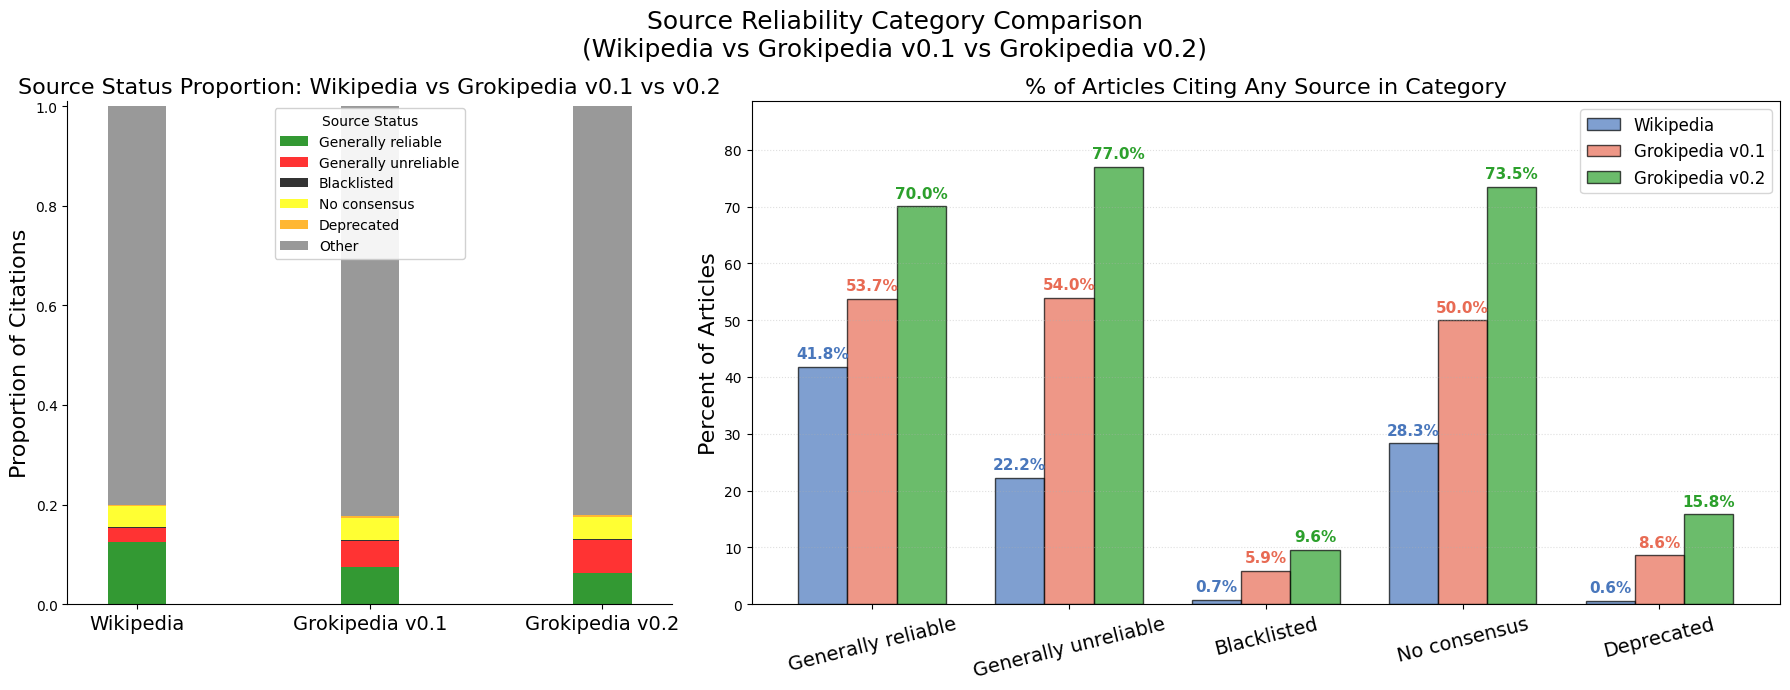

In [12]:
plot_reliability_charts(max_reliability_shift_df, fsuffix='_grok_v0_2', title='Source Reliability Category Comparison\n(Wikipedia vs Grokipedia v0.1 vs Grokipedia v0.2)')

In [13]:
def find_reliability_shift_by_buckets(reliability_df,
                                      grok_v01_idx_path='../results/overall/cached_grok_idx.pkl',
                                      grok_v02_idx_path='../results/v0.2_scrape/cached_grokipedia_idx_v0_2.pkl',
                                      wiki_idx_path='../results/overall/cached_wiki_idx.pkl',
                                      grok_v01_jsonl_path='../grokipedia_scrape.ndjson',
                                      grok_v02_jsonl_path='../results/v0.2_scrape/scraped_data.jsonl',
                                      wiki_jsonl_path='../grokipedia_wikipedia_articles.ndjson'):
    """
    Find articles where reliability shifts occur, grouped by reliability score buckets (0.2-sized buckets).
    Uses reliability_df DataFrame with reliability_score instead of discrete status categories.
    Only processes articles that exist in ALL THREE sources (Wikipedia, Grokipedia v0.1, and v0.2).
    Keyed on v0.2 titles - iterates over v0.2 index and requires matching entries in Wikipedia and v0.1.
    
    Args:
        reliability_df: DataFrame with 'domain' and 'reliability_score' (or 'pc1') columns
        grok_v01_idx_path: Path to cached Grokipedia v0.1 index pickle file
        grok_v02_idx_path: Path to cached Grokipedia v0.2 index pickle file
        wiki_idx_path: Path to cached Wikipedia index pickle file
        grok_v01_jsonl_path: Path to Grokipedia v0.1 scraped data JSONL file
        grok_v02_jsonl_path: Path to Grokipedia v0.2 scraped data JSONL file
        wiki_jsonl_path: Path to Wikipedia articles JSONL file
    
    Returns:
        List of tuples with article shift data grouped by reliability score buckets for all three sources
    """
    import pickle
    from urllib.parse import urlparse
    import re
    import pandas as pd
    
    # Define buckets: 0-0.2, 0.2-0.4, 0.4-0.6, 0.6-0.8, 0.8-1.0
    bucket_size = 0.2
    buckets = [(i * bucket_size, (i + 1) * bucket_size) for i in range(5)]
    bucket_labels = [f"{i * bucket_size:.1f}-{(i + 1) * bucket_size:.1f}" for i in range(5)]
    
    def get_bucket(score):
        """Assign a reliability score to a bucket."""
        if pd.isna(score):
            return None
        for i, (low, high) in enumerate(buckets):
            if low <= score < high:
                return i
        # Handle edge case: score == 1.0
        if score == 1.0:
            return 4
        return None
    
    def stem_domain(domain):
        # Remove common www/amp/mobile etc, keep only base domain
        if domain.startswith("www."):
            domain = domain[4:]
        # Remove mobile/amp subdomains if desired
        domain = re.sub(r"^(m|amp|en|web|mobile)\.", "", domain)
        return domain.lower()
    
    # Load cached indexes
    print("Loading cached indexes...")
    with open(grok_v01_idx_path, 'rb') as f:
        grok_v01_idx = pickle.load(f)
    with open(grok_v02_idx_path, 'rb') as f:
        grok_v02_idx = pickle.load(f)
    with open(wiki_idx_path, 'rb') as f:
        wiki_idx = pickle.load(f)
    
    print(f"  Grokipedia v0.1 index: {len(grok_v01_idx)} entries")
    print(f"  Grokipedia v0.2 index: {len(grok_v02_idx)} entries")
    print(f"  Wikipedia index: {len(wiki_idx)} entries")
    
    # Create lookup dict for reliability score by normalized domain
    # Handle both 'reliability_score' and 'pc1' column names
    score_col = 'reliability_score' if 'reliability_score' in reliability_df.columns else 'pc1'
    reliability_lookup = {}
    for _, row in reliability_df.iterrows():
        domain = row['domain']
        if domain and pd.notna(row.get(score_col)):
            stemmed = stem_domain(domain)
            reliability_lookup[stemmed] = row[score_col]
    
    def get_article_reliability_bucket_counts_from_page(page_obj, is_grok=True):
        """Extract references from a page object and count by reliability score bucket."""
        # Initialize counts for each bucket
        bucket_counts = {i: 0 for i in range(5)}
        other_count = 0
        total_count = 0
        
        if is_grok:
            # Grokipedia structure: data['references'] with link['href']
            refs = page_obj.get('data', {}).get('references', [])
            for ref in refs:
                link = ref.get('link') if isinstance(ref, dict) else None
                href = link.get('href') if (link and isinstance(link, dict)) else None
                if href:
                    domain = urlparse(href).netloc
                    if domain:
                        stemmed = stem_domain(domain)
                        total_count += 1
                        if stemmed in reliability_lookup:
                            score = reliability_lookup[stemmed]
                            bucket_idx = get_bucket(score)
                            if bucket_idx is not None:
                                bucket_counts[bucket_idx] += 1
                            else:
                                other_count += 1
                        else:
                            other_count += 1
        else:
            # Wikipedia structure: references with metadata['url']
            refs = page_obj.get('references', [])
            for ref in refs:
                metadata = ref.get('metadata') if isinstance(ref, dict) else None
                url = metadata.get('url') if (metadata and isinstance(metadata, dict)) else None
                if url:
                    domain = urlparse(url).netloc
                    if domain:
                        stemmed = stem_domain(domain)
                        total_count += 1
                        if stemmed in reliability_lookup:
                            score = reliability_lookup[stemmed]
                            bucket_idx = get_bucket(score)
                            if bucket_idx is not None:
                                bucket_counts[bucket_idx] += 1
                            else:
                                other_count += 1
                        else:
                            other_count += 1
        
        return (bucket_counts[0], bucket_counts[1], bucket_counts[2], bucket_counts[3], bucket_counts[4], other_count, total_count)
    
    # Process all articles in Grokipedia v0.2 index that also exist in Wikipedia and v0.1
    print("Processing articles (intersection of all three sources, keyed on v0.2)...")
    article_bucket_shifts = []
    processed = 0
    skipped = 0
    
    for norm_title, grok_v02_info in grok_v02_idx.items():
        # Check if article exists in all three sources
        wiki_offset = wiki_idx.get(norm_title)
        grok_v01_offset = grok_v01_idx.get(norm_title)
        
        # Skip if not in all three sources
        if wiki_offset is None or grok_v01_offset is None:
            skipped += 1
            continue
        
        # Load Grokipedia v0.2 page
        if isinstance(grok_v02_info, tuple):
            # Grok index stores (filename, offset)
            grok_v02_file, grok_v02_offset = grok_v02_info
        else:
            # Fallback: assume it's just an offset
            grok_v02_file = grok_v02_jsonl_path
            grok_v02_offset = grok_v02_info
        
        try:
            grok_v02_page = get_object_at_offset(grok_v02_file, grok_v02_offset)
            grok_v01_page = get_object_at_offset(grok_v01_jsonl_path, grok_v01_offset)
            wiki_page = get_object_at_offset(wiki_jsonl_path, wiki_offset)
        except Exception as e:
            skipped += 1
            continue
        
        # Get article title from v0.2 page
        article_title = grok_v02_page.get('data', {}).get('main_title', norm_title)
        if not article_title:
            article_title = norm_title
        
        # Get reliability bucket counts from all three sources
        wp_b0, wp_b1, wp_b2, wp_b3, wp_b4, wp_other, wp_total = \
            get_article_reliability_bucket_counts_from_page(wiki_page, is_grok=False)
        grok_v01_b0, grok_v01_b1, grok_v01_b2, grok_v01_b3, grok_v01_b4, grok_v01_other, grok_v01_total = \
            get_article_reliability_bucket_counts_from_page(grok_v01_page, is_grok=True)
        grok_v02_b0, grok_v02_b1, grok_v02_b2, grok_v02_b3, grok_v02_b4, grok_v02_other, grok_v02_total = \
            get_article_reliability_bucket_counts_from_page(grok_v02_page, is_grok=True)
        
        # Calculate shifts for each bucket: WP_count - Grok_count (using v0.2, not v0.1)
        # Positive means WP has more, negative means Grok has more
        shifts = [
            wp_b0 - grok_v02_b0,
            wp_b1 - grok_v02_b1,
            wp_b2 - grok_v02_b2,
            wp_b3 - grok_v02_b3,
            wp_b4 - grok_v02_b4
        ]
        
        # Calculate overall shift metric: weighted sum (higher buckets weighted more)
        # This gives more weight to shifts in higher reliability buckets
        weighted_shift = sum(shifts[i] * (i + 1) for i in range(5))
        
        article_bucket_shifts.append((
            article_title,
            # Wikipedia buckets
            wp_b0, wp_b1, wp_b2, wp_b3, wp_b4, wp_other, wp_total,
            # Grokipedia v0.1 buckets
            grok_v01_b0, grok_v01_b1, grok_v01_b2, grok_v01_b3, grok_v01_b4, grok_v01_other, grok_v01_total,
            # Grokipedia v0.2 buckets
            grok_v02_b0, grok_v02_b1, grok_v02_b2, grok_v02_b3, grok_v02_b4, grok_v02_other, grok_v02_total,
            # Individual bucket shifts (WP - Grok v0.2)
            shifts[0], shifts[1], shifts[2], shifts[3], shifts[4],
            # Overall weighted shift
            weighted_shift
        ))
        
        processed += 1
        if processed % 1000 == 0:
            print(f"  Processed {processed} articles...")
    
    print(f"\nProcessed {processed} articles, skipped {skipped} articles")
    print(f"Returning {len(article_bucket_shifts)} results")
    
    return article_bucket_shifts

bucket_columns = [
    'title',
    # Wikipedia buckets
    'wp_bucket_0_0.2', 'wp_bucket_0.2_0.4', 'wp_bucket_0.4_0.6', 'wp_bucket_0.6_0.8', 'wp_bucket_0.8_1.0', 'wp_other', 'wp_total',
    # Grokipedia v0.1 buckets
    'grok_v01_bucket_0_0.2', 'grok_v01_bucket_0.2_0.4', 'grok_v01_bucket_0.4_0.6', 'grok_v01_bucket_0.6_0.8', 'grok_v01_bucket_0.8_1.0', 'grok_v01_other', 'grok_v01_total',
    # Grokipedia v0.2 buckets
    'grok_v02_bucket_0_0.2', 'grok_v02_bucket_0.2_0.4', 'grok_v02_bucket_0.4_0.6', 'grok_v02_bucket_0.6_0.8', 'grok_v02_bucket_0.8_1.0', 'grok_v02_other', 'grok_v02_total',
    # Individual bucket shifts (WP - Grok v0.2)
    'shift_bucket_0_0.2', 'shift_bucket_0.2_0.4', 'shift_bucket_0.4_0.6', 'shift_bucket_0.6_0.8', 'shift_bucket_0.8_1.0',
    # Overall weighted shift
    'weighted_shift'
]

In [ ]:
lin_reliability = pd.read_csv(f'../supplemental_data/news_reliability/LinRating_Join.csv')
lin_reliability['reliability_score'] = lin_reliability['pc1']

article_maximals_lin = find_reliability_shift_by_buckets(lin_reliability)
max_reliability_shift_df_lin = pd.DataFrame(article_maximals_lin, columns=bucket_columns)

In [18]:
def plot_reliability_bucket_charts(filtered_df, fsuffix='', show=True, title=None):
    """
    Plots stacked bar + diagonal comparison charts using reliability score buckets for three sources:
    Wikipedia, Grokipedia v0.1, and Grokipedia v0.2.
    1. Stacked bar: Proportion of sources in each reliability bucket for all three sources.
    2. Bar chart: Percentage of articles containing at least one source in each bucket for all three sources.

    Parameters:
        filtered_df (pd.DataFrame): DataFrame with bucket columns (from find_reliability_shift_by_buckets)
        fsuffix (str): Suffix for output filename
        show (bool): If True, calls plt.show() at end.
        title (str): Optional custom title for the whole figure. If None, uses default title.
    """

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch
    import matplotlib.colors as mcolors

    # --- Setup buckets, labels, colors ---
    bucket_labels = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0', 'other']
    display_names = {
        '0.0-0.2': '0.0-0.2',
        '0.2-0.4': '0.2-0.4',
        '0.4-0.6': '0.4-0.6',
        '0.6-0.8': '0.6-0.8',
        '0.8-1.0': '0.8-1.0',
        'other': 'No score'
    }
    
    # Create color map: green (for 1.0), yellow (for 0.5), red (for 0.0), gray for 'other'
    from matplotlib.colors import to_hex, LinearSegmentedColormap
    
    # Create a green-yellow-red colormap, where 1.0 is green, 0.5 is yellow, 0.0 is red
    spect_cmap = LinearSegmentedColormap.from_list(
        "green_yellow_red", [(0.0, "#D73027"), (0.5, "#FEE08B"), (1.0, "#1A9850")]  # red, yellow, green
    )
    
    # Map bucket labels to their midpoint values for colormap
    bucket_midpoints = {
        '0.0-0.2': 0.1,  # Red end
        '0.2-0.4': 0.3,  # Red-yellow transition
        '0.4-0.6': 0.5,  # Yellow (middle)
        '0.6-0.8': 0.7,  # Yellow-green transition
        '0.8-1.0': 0.9,  # Green end
    }
    
    # Generate colors for each bucket using the colormap
    color_map = {}
    for bucket_label in bucket_labels:
        if bucket_label == 'other':
            color_map[bucket_label] = 'grey'
        else:
            midpoint = bucket_midpoints[bucket_label]
            color_map[bucket_label] = to_hex(spect_cmap(midpoint))

    # --- Aggregate counts for all three sources ---
    # Map bucket labels to actual column name suffixes
    bucket_to_col = {
        '0.0-0.2': '0_0.2',
        '0.2-0.4': '0.2_0.4',
        '0.4-0.6': '0.4_0.6',
        '0.6-0.8': '0.6_0.8',
        '0.8-1.0': '0.8_1.0'
    }
    
    sources = ['Wikipedia', 'Grokipedia v0.1', 'Grokipedia v0.2']
    source_prefixes = ['wp', 'grok_v01', 'grok_v02']
    
    agg = {}
    for source_prefix in source_prefixes:
        for bucket_label in bucket_labels:
            if bucket_label == 'other':
                col = f'{source_prefix}_other'
                if col in filtered_df.columns:
                    agg[f'{source_prefix}_{bucket_label}'] = filtered_df[col].sum()
                else:
                    agg[f'{source_prefix}_{bucket_label}'] = 0
            else:
                col_suffix = bucket_to_col[bucket_label]
                col = f'{source_prefix}_bucket_{col_suffix}'
                if col in filtered_df.columns:
                    agg[f'{source_prefix}_{bucket_label}'] = filtered_df[col].sum()
                else:
                    agg[f'{source_prefix}_{bucket_label}'] = 0

    # Make DF of shape: index=['Wikipedia', 'Grokipedia v0.1', 'Grokipedia v0.2'], columns=bucket_labels
    rows = []
    for prefix in source_prefixes:
        row = [agg.get(f'{prefix}_{k}', 0) for k in bucket_labels]
        rows.append(row)
    
    prop_df = pd.DataFrame(rows, columns=bucket_labels, index=sources)
    prop_df_norm = prop_df.div(prop_df.sum(axis=1), axis=0).fillna(0)

    # --- Plotting stacked bars ---
    labels = sources
    x = np.arange(len(labels))
    width = 0.25  # Width of each bar

    fig, axs = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1.7]})
    ax = axs[0]

    # Set up stacking for three bars
    bottoms = [0, 0, 0]
    bars = [[], [], []]

    print("Wikipedia proportions:")
    print(prop_df_norm.loc['Wikipedia'])
    print("\nGrokipedia v0.1 proportions:")
    print(prop_df_norm.loc['Grokipedia v0.1'])
    print("\nGrokipedia v0.2 proportions:")
    print(prop_df_norm.loc['Grokipedia v0.2'])

    # For synchronized stacking, process in bucket order:
    for j, bucket_label in enumerate(bucket_labels):
        color = color_map.get(bucket_label, 'grey')
        for i, source in enumerate(sources):
            prop = prop_df_norm.loc[source, bucket_label]
            bar = ax.bar(x[i], prop, width=width, bottom=bottoms[i],
                        color=color, edgecolor='none', zorder=2, alpha=0.8)
            bars[i].append(bar)
            bottoms[i] += prop

    # Set axis ticks and labels
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=14)
    ax.set_ylabel("Proportion of Citations", fontsize=16)
    ax.set_title("Source Reliability Score Proportion: Wikipedia vs Grokipedia v0.1 vs v0.2", fontsize=16)

    # Make axis tight with bars
    ax.set_xlim(-0.3, 2.3)
    ax.set_ylim(bottom=0, top=1.01)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # Custom legend patch (color by bucket) - reversed order
    legend_elements = [Patch(facecolor=color_map.get(bucket_label, 'grey'), 
                            label=display_names.get(bucket_label, bucket_label), alpha=0.8) 
                       for bucket_label in reversed(bucket_labels)]
    ax.legend(handles=legend_elements, title='Reliability Score', loc='upper center', framealpha=0.9, fontsize=10)

    # Set figure title (for whole figure)
    plot_title = title if title is not None else "Source Reliability Score Proportion: Wikipedia vs Grokipedia v0.1 vs v0.2"
    fig.suptitle(plot_title, fontsize=18, y=0.98)
    
    # Tighten subplot spacing
    fig.subplots_adjust(wspace=0.15, left=0.05, right=0.97, top=0.92, bottom=0.1)

    # ---- Second plot: % of articles containing at least 1 in each bucket ----
    ax2 = axs[1]
    main_buckets = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
    bucket_display_labels = [display_names[b] for b in main_buckets]
    bar_x = np.arange(len(main_buckets))
    bar_width = 0.25

    n_articles = len(filtered_df)
    percentages = {source: [] for source in sources}
    
    # Print the number of articles containing at least one 0-0.2-reliability citation
    wp_0_0_2_col = 'wp_bucket_0_0.2'
    grok_v01_0_0_2_col = 'grok_v01_bucket_0_0.2'
    grok_v02_0_0_2_col = 'grok_v02_bucket_0_0.2'
    
    wp_0_0_2_num = (filtered_df[wp_0_0_2_col] > 0).sum() if wp_0_0_2_col in filtered_df.columns else 0
    grok_v01_0_0_2_num = (filtered_df[grok_v01_0_0_2_col] > 0).sum() if grok_v01_0_0_2_col in filtered_df.columns else 0
    grok_v02_0_0_2_num = (filtered_df[grok_v02_0_0_2_col] > 0).sum() if grok_v02_0_0_2_col in filtered_df.columns else 0
    
    print(f"Number of articles with at least one 0-0.2 source: Wikipedia: {wp_0_0_2_num}, Grokipedia v0.1: {grok_v01_0_0_2_num}, Grokipedia v0.2: {grok_v02_0_0_2_num}")
    print(f"Number of pages with a 0-0.2 source in Wikipedia: {wp_0_0_2_num}")
    print(f"Number of pages with a 0-0.2 source in Grokipedia v0.1: {grok_v01_0_0_2_num}")
    print(f"Number of pages with a 0-0.2 source in Grokipedia v0.2: {grok_v02_0_0_2_num}")

    for bucket_label in main_buckets:
        col_suffix = bucket_to_col[bucket_label]
        for i, prefix in enumerate(source_prefixes):
            col = f'{prefix}_bucket_{col_suffix}'
            if col in filtered_df.columns:
                count = (filtered_df[col] > 0).sum()
                percentages[sources[i]].append(count / n_articles * 100)
            else:
                percentages[sources[i]].append(0)

    # Plot as side-by-side bars
    colors = ["#4977bc", "#e86b54", "#2ca02c"]  # Blue, Red, Green
    for i, source in enumerate(sources):
        offset = (i - 1) * bar_width
        ax2.bar(bar_x + offset, percentages[source], bar_width,
               label=source, color=colors[i], edgecolor='black', alpha=0.7)
        
        # Add percentage labels
        for j, pct in enumerate(percentages[source]):
            ax2.text(j + offset, pct + 1, f"{pct:.1f}%", ha='center', va='bottom', 
                    fontsize=11, color=colors[i], weight='bold')

    ax2.set_xticks(bar_x)
    ax2.set_xticklabels(bucket_display_labels, rotation=14, fontsize=14)
    ax2.set_ylim(0, max(max(p) for p in percentages.values()) * 1.15 if percentages else 105)
    ax2.set_ylabel("Percent of Articles", fontsize=16)
    ax2.set_title("% of Articles Citing Any Source in Reliability Bucket", fontsize=16)
    ax2.legend(loc='upper left', fontsize=12)
    ax2.grid(axis='y', linestyle=':', alpha=0.4)

    fig.tight_layout()
    fig.savefig(f'../graphics/overall_grok_wp_cite_composition_lin_{fsuffix}.pdf')

    if show:
        plt.show()

Wikipedia proportions:
0.0-0.2    0.000076
0.2-0.4    0.012197
0.4-0.6    0.023986
0.6-0.8    0.118389
0.8-1.0    0.145686
other      0.699666
Name: Wikipedia, dtype: float64

Grokipedia v0.1 proportions:
0.0-0.2    0.000285
0.2-0.4    0.011902
0.4-0.6    0.023177
0.6-0.8    0.078561
0.8-1.0    0.131873
other      0.754202
Name: Grokipedia v0.1, dtype: float64

Grokipedia v0.2 proportions:
0.0-0.2    0.000224
0.2-0.4    0.012989
0.4-0.6    0.021213
0.6-0.8    0.065502
0.8-1.0    0.118557
other      0.781515
Name: Grokipedia v0.2, dtype: float64
Number of articles with at least one 0-0.2 source: Wikipedia: 45, Grokipedia v0.1: 268, Grokipedia v0.2: 312
Number of pages with a 0-0.2 source in Wikipedia: 45
Number of pages with a 0-0.2 source in Grokipedia v0.1: 268
Number of pages with a 0-0.2 source in Grokipedia v0.2: 312


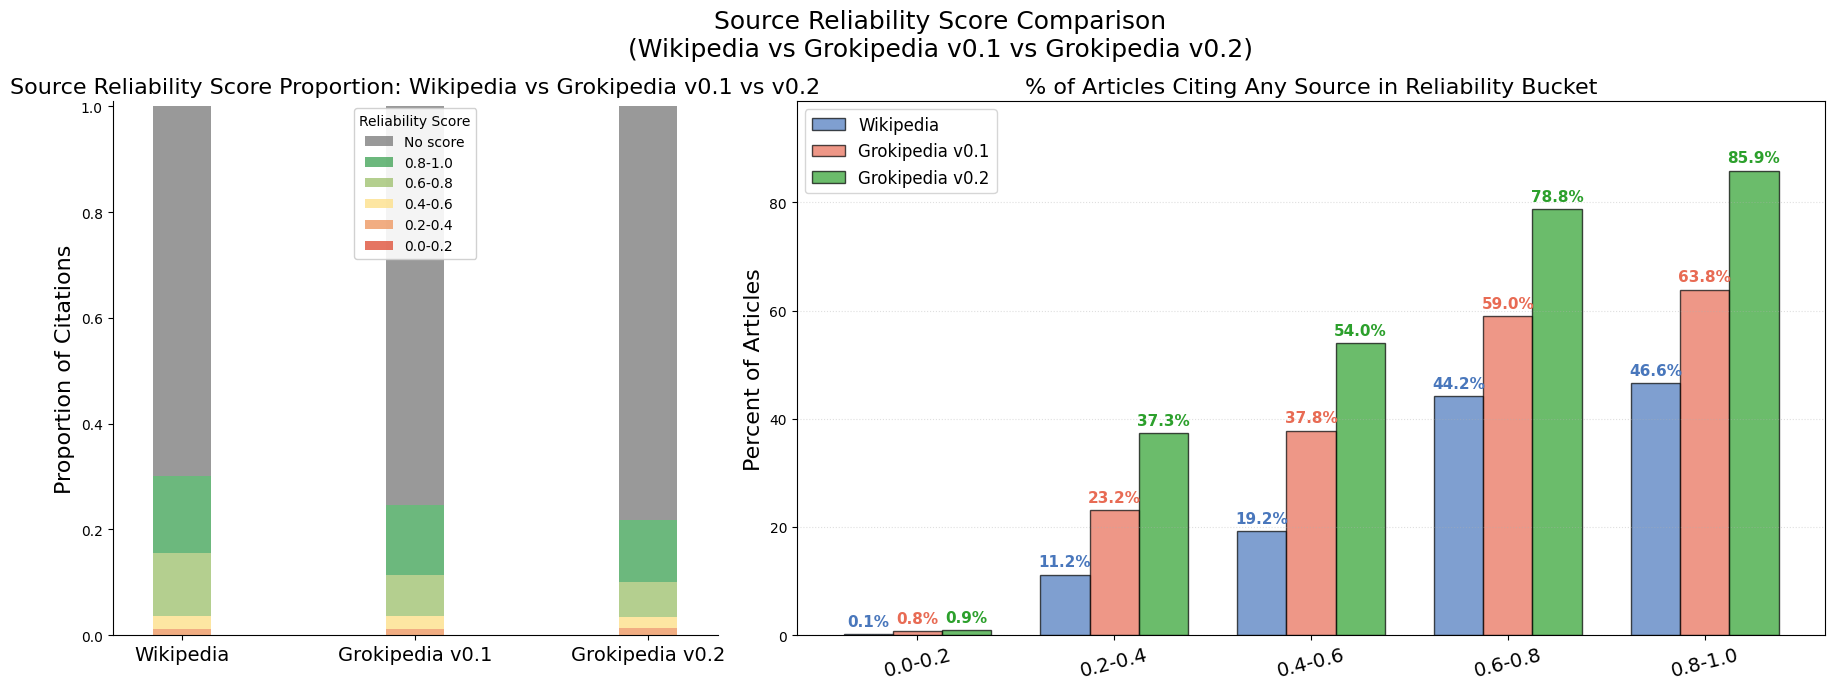

In [19]:
plot_reliability_bucket_charts(max_reliability_shift_df_lin, fsuffix='_grok_v0_2', title='Source Reliability Score Comparison\n(Wikipedia vs Grokipedia v0.1 vs Grokipedia v0.2)')

In [3]:
import pandas as pd
import json
from collections import Counter
import numpy as np

# Load internal links data
with open('../results/v0.2_scrape/grok_sample_internal_links.json', 'r', encoding='utf-8') as f:
    internal_links_data = json.load(f)

print(f"Loaded {len(internal_links_data)} articles with internal link data\n")

# Convert to a more analyzable format
all_links = []
article_link_counts = []
link_target_counts = Counter()
total_links = 0

for article_dict in internal_links_data:
    for article_title, links_dict in article_dict.items():
        if isinstance(links_dict, dict):
            num_links = sum(links_dict.values())
            article_link_counts.append((article_title, num_links))
            total_links += num_links
            
            # Count how many times each target is linked to
            for target, count in links_dict.items():
                link_target_counts[target] += count
                all_links.append({
                    'source': article_title,
                    'target': target,
                    'count': count
                })

print(f"Total internal links: {total_links:,}")
print(f"Unique source articles: {len(article_link_counts):,}")
print(f"Unique target articles: {len(link_target_counts):,}\n")

# Articles with most outgoing links
print("=== Articles with Most Outgoing Links ===")
article_link_counts_sorted = sorted(article_link_counts, key=lambda x: x[1], reverse=True)
for title, count in article_link_counts_sorted[:20]:
    print(f"  {title}: {count:,} links")

# Most linked-to articles (in-degree)
print("\n=== Most Linked-To Articles (In-Degree) ===")
most_linked = link_target_counts.most_common(20)
for target, count in most_linked:
    print(f"  {target}: {count:,} incoming links")

# Articles with no outgoing links
articles_with_links = {title for title, _ in article_link_counts}
print(f"\n=== Articles with No Outgoing Links ===")
print(f"Count: {len(internal_links_data) - len(articles_with_links)}")

# Articles with no incoming links (orphans)
all_article_titles = set()
for article_dict in internal_links_data:
    all_article_titles.update(article_dict.keys())

articles_with_incoming = set(link_target_counts.keys())
orphans = all_article_titles - articles_with_incoming
print(f"\n=== Articles with No Incoming Links (Orphans) ===")
print(f"Count: {len(orphans):,}")
if len(orphans) <= 20:
    for title in sorted(orphans):
        print(f"  {title}")
else:
    print(f"Sample (first 20):")
    for title in sorted(list(orphans))[:20]:
        print(f"  {title}")

# Link distribution statistics
link_counts = [count for _, count in article_link_counts]
print(f"\n=== Outgoing Links Distribution ===")
print(f"Mean links per article: {np.mean(link_counts):.2f}")
print(f"Median links per article: {np.median(link_counts):.2f}")
print(f"Min links: {min(link_counts)}")
print(f"Max links: {max(link_counts):,}")
print(f"Std dev: {np.std(link_counts):.2f}")

# In-degree distribution
in_degrees = list(link_target_counts.values())
print(f"\n=== Incoming Links Distribution ===")
print(f"Mean incoming links per article: {np.mean(in_degrees):.2f}")
print(f"Median incoming links per article: {np.median(in_degrees):.2f}")
print(f"Min incoming links: {min(in_degrees)}")
print(f"Max incoming links: {max(in_degrees):,}")
print(f"Std dev: {np.std(in_degrees):.2f}")

# Create DataFrame for further analysis
links_df = pd.DataFrame(all_links)
print(f"\n=== DataFrame Created ===")
print(f"Links DataFrame shape: {links_df.shape}")
print(f"Sample of links DataFrame:")
print(links_df.head(10))

# Articles with most self-links (if any)
self_links = links_df[links_df['source'] == links_df['target']]
if len(self_links) > 0:
    print(f"\n=== Self-Links ===")
    print(f"Total self-links: {self_links['count'].sum():,}")
    print(f"Articles with self-links: {len(self_links['source'].unique())}")
    self_link_counts = self_links.groupby('source')['count'].sum().sort_values(ascending=False)
    print("Top 10 articles with most self-links:")
    for title, count in self_link_counts.head(10).items():
        print(f"  {title}: {count}")

# Reciprocal links analysis (A links to B and B links to A)
print(f"\n=== Reciprocal Links Analysis ===")
# Create a set of (source, target) pairs
link_pairs = set()
for _, row in links_df.iterrows():
    link_pairs.add((row['source'], row['target']))

reciprocal_count = 0
for source, target in link_pairs:
    if (target, source) in link_pairs:
        reciprocal_count += 1

print(f"Total link pairs: {len(link_pairs):,}")
print(f"Reciprocal pairs: {reciprocal_count:,}")
if len(link_pairs) > 0:
    print(f"Reciprocity rate: {reciprocal_count / len(link_pairs) * 100:.2f}%")

# Link density
print(f"\n=== Network Density ===")
n = len(all_article_titles)
max_possible_links = n * (n - 1)  # Directed graph, no self-loops
actual_links = len(link_pairs)
density = actual_links / max_possible_links if max_possible_links > 0 else 0
print(f"Number of articles: {n:,}")
print(f"Max possible links: {max_possible_links:,}")
print(f"Actual unique link pairs: {actual_links:,}")
print(f"Network density: {density:.6f}")

# Save summary statistics
summary_stats = {
    'total_articles': len(all_article_titles),
    'articles_with_outgoing_links': len(articles_with_links),
    'articles_with_incoming_links': len(articles_with_incoming),
    'orphan_articles': len(orphans),
    'total_link_instances': total_links,
    'unique_link_pairs': len(link_pairs),
    'reciprocal_pairs': reciprocal_count,
    'network_density': density,
    'mean_outgoing_links': np.mean(link_counts),
    'median_outgoing_links': np.median(link_counts),
    'mean_incoming_links': np.mean(in_degrees),
    'median_incoming_links': np.median(in_degrees),
}

print(f"\n=== Summary Statistics ===")
for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value:,}")

# Optionally save to JSON
# with open('../results/v0.2_scrape/internal_links_analysis.json', 'w') as f:
#     json.dump(summary_stats, f, indent=2)

Loaded 48307 articles with internal link data

Total internal links: 6,299,545
Unique source articles: 48,307
Unique target articles: 786,833

=== Articles with Most Outgoing Links ===
  List_of_conglomerates: 976 links
  List_of_Marvel_Comics_characters:_F: 894 links
  List_of_food_companies: 873 links
  Glossary_of_psychiatry: 871 links
  List_of_mammals_of_North_America: 852 links
  Outline_of_culture: 832 links
  List_of_cancelled_military_projects: 821 links
  Glossary_of_computer_science: 804 links
  Western_culture: 791 links
  List_of_birds_of_China: 780 links
  List_of_birds_of_Canada: 765 links
  List_of_birds_of_Asia: 759 links
  Timeline_of_Christianity: 727 links
  DSM-IV_codes: 725 links
  List_of_EC_numbers_(EC_1): 720 links
  List_of_Unicode_characters: 715 links
  List_of_orders_of_battle: 712 links
  List_of_road–rail_bridges: 708 links
  Cold_War: 686 links
  Virginia: 685 links

=== Most Linked-To Articles (In-Degree) ===
  united_states: 12,523 incoming links
  eur

In [ ]:
internal_link_df

In [1]:
import json
import re
from typing import Dict, Any, List

from tqdm import tqdm

def extract_text_from_wikipedia_section(section: Dict[str, Any]) -> str:
    """
    Recursively extract all text from a Wikipedia section and its nested parts.
    Wikipedia has recursive structure: sections -> has_parts -> (paragraphs, lists, nested sections)
    """
    text_parts = []
    
    if not isinstance(section, dict):
        return ""
    
    # Extract text from has_parts
    has_parts = section.get("has_parts", [])
    if isinstance(has_parts, list):
        for part in has_parts:
            if not isinstance(part, dict):
                continue
            
            part_type = part.get("type", "")
            
            if part_type == "paragraph":
                value = part.get("value", "")
                if value and isinstance(value, str):
                    text_parts.append(value)
            
            elif part_type == "list":
                items = part.get("items", [])
                for item in items:
                    if isinstance(item, str):
                        text_parts.append(item)
                    elif isinstance(item, dict):
                        # Handle nested list items
                        item_text = item.get("value") or item.get("text") or ""
                        if item_text:
                            text_parts.append(item_text)
            
            elif part_type == "section":
                # Recursively handle nested sections
                nested_text = extract_text_from_wikipedia_section(part)
                if nested_text:
                    text_parts.append(nested_text)
            
            else:
                # Try to extract any text value
                value = part.get("value") or part.get("text") or ""
                if value and isinstance(value, str):
                    text_parts.append(value)
    
    return " ".join(text_parts)

def extract_text_from_wikipedia_article(article: Dict[str, Any]) -> str:
    """
    Extract all text from a Wikipedia article, handling recursive section structure.
    """
    text_parts = []
    
    # Extract abstract if present
    abstract = article.get("abstract", "")
    if abstract and isinstance(abstract, str):
        text_parts.append(abstract)
    
    # Extract text from all sections recursively
    sections = article.get("sections", [])
    if isinstance(sections, list):
        for section in sections:
            section_text = extract_text_from_wikipedia_section(section)
            if section_text:
                text_parts.append(section_text)
    
    return " ".join(text_parts)

def extract_text_from_grokipedia_article(article: Dict[str, Any]) -> str:
    """
    Extract all text from a Grokipedia article (v0.1 or v0.2).
    Grokipedia has flat structure: data.sections -> content -> text
    """
    text_parts = []
    
    # Get data section (for v0.1 and v0.2)
    data = article.get("data", {})
    if not data:
        # Fallback: try direct access
        data = article
    
    # Extract text from sections
    sections = data.get("sections", [])
    if isinstance(sections, list):
        for section in sections:
            if not isinstance(section, dict):
                continue
            
            content = section.get("content", [])
            if isinstance(content, list):
                for item in content:
                    if isinstance(item, dict):
                        # Extract text from paragraph items
                        text = item.get("text", "")
                        if text and isinstance(text, str):
                            text_parts.append(text)
                        
                        # Extract text from list items
                        items = item.get("items", [])
                        if isinstance(items, list):
                            for list_item in items:
                                if isinstance(list_item, str):
                                    text_parts.append(list_item)
                    elif isinstance(item, str):
                        text_parts.append(item)
    
    # Also check for paragraphs field (some Grokipedia versions)
    paragraphs = data.get("paragraphs", [])
    if isinstance(paragraphs, list):
        for para in paragraphs:
            if isinstance(para, str):
                text_parts.append(para)
            elif isinstance(para, dict):
                text = para.get("text", "")
                if text:
                    text_parts.append(text)
    
    return " ".join(text_parts)

def count_words(text: str) -> int:
    """Count words in text (split on whitespace)."""
    if not text:
        return 0
    # Split on whitespace and filter out empty strings
    words = [w for w in text.split() if w.strip()]
    return len(words)

def calculate_average_word_counts(
    wiki_path: str = '../grokipedia_wikipedia_articles.ndjson',
    grok_v01_path: str = '../grokipedia_scrape.ndjson',
    grok_v02_path: str = '../results/v0.2_scrape/scraped_data.jsonl'
):
    """
    Calculate average word counts for Wikipedia, Grokipedia v0.1, and Grokipedia v0.2 articles.
    
    Returns:
        dict with word count statistics for each source
    """
    results = {
        'wikipedia': {'counts': [], 'total_articles': 0, 'failed': 0},
        'grok_v01': {'counts': [], 'total_articles': 0, 'failed': 0},
        'grok_v02': {'counts': [], 'total_articles': 0, 'failed': 0}
    }

    # Process Wikipedia articles
    print("Processing Wikipedia articles...")
    wiki_total = 964491
    try:
        with open(wiki_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(tqdm(f, total=wiki_total, desc="Wikipedia"), 1):
                if not line.strip():
                    continue
                # try:
                article = json.loads(line)
                text = extract_text_from_wikipedia_article(article)
                word_count = count_words(text)
                results['wikipedia']['counts'].append(word_count)
                results['wikipedia']['total_articles'] += 1
                # except Exception as e:
                #     results['wikipedia']['failed'] += 1
                #     if results['wikipedia']['failed'] <= 5:
                #         print(f"  Warning: Failed to process Wikipedia article at line {line_num}: {e}")
    except FileNotFoundError:
        print(f"  Warning: Wikipedia file not found: {wiki_path}")
    except Exception as e:
        print(f"  Error processing Wikipedia file: {e}")
    
    # Process Grokipedia v0.1 articles
    print("Processing Grokipedia v0.1 articles...")
    grok_v01_total = 883858
    try:
        with open(grok_v01_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(tqdm(f, total=grok_v01_total, desc="Grokipedia v0.1"), 1):
                if not line.strip():
                    continue
                # try:
                article = json.loads(line)
                text = extract_text_from_grokipedia_article(article)
                word_count = count_words(text)
                results['grok_v01']['counts'].append(word_count)
                results['grok_v01']['total_articles'] += 1
                # except Exception as e:
                #     results['grok_v01']['failed'] += 1
                #     if results['grok_v01']['failed'] <= 5:
                #         print(f"  Warning: Failed to process Grokipedia v0.1 article at line {line_num}: {e}")
    except FileNotFoundError:
        print(f"  Warning: Grokipedia v0.1 file not found: {grok_v01_path}")
    except Exception as e:
        print(f"  Error processing Grokipedia v0.1 file: {e}")
    
    # Process Grokipedia v0.2 articles
    print("Processing Grokipedia v0.2 articles...")
    grok_v02_total = 48307
    try:
        with open(grok_v02_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(tqdm(f, total=grok_v02_total, desc="Grokipedia v0.2"), 1):
                if not line.strip():
                    continue
                # try:
                article = json.loads(line)
                text = extract_text_from_grokipedia_article(article)
                word_count = count_words(text)
                results['grok_v02']['counts'].append(word_count)
                results['grok_v02']['total_articles'] += 1
                # except Exception as e:
                #     results['grok_v02']['failed'] += 1
                #     if results['grok_v02']['failed'] <= 5:
                #         print(f"  Warning: Failed to process Grokipedia v0.2 article at line {line_num}: {e}")
    except FileNotFoundError:
        print(f"  Warning: Grokipedia v0.2 file not found: {grok_v02_path}")
    except Exception as e:
        print(f"  Error processing Grokipedia v0.2 file: {e}")
    
    # Calculate statistics
    print("\n=== Word Count Statistics ===")
    for source_name, source_data in results.items():
        counts = source_data['counts']
        if counts:
            avg = sum(counts) / len(counts)
            median = sorted(counts)[len(counts) // 2] if counts else 0
            min_count = min(counts)
            max_count = max(counts)
            total_words = sum(counts)
            
            print(f"\n{source_name.upper()}:")
            print(f"  Total articles processed: {source_data['total_articles']:,}")
            print(f"  Failed articles: {source_data['failed']:,}")
            print(f"  Average word count: {avg:,.1f}")
            print(f"  Median word count: {median:,}")
            print(f"  Min word count: {min_count:,}")
            print(f"  Max word count: {max_count:,}")
            print(f"  Total words: {total_words:,}")
        else:
            print(f"\n{source_name.upper()}:")
            print(f"  No articles processed")
            print(f"  Failed articles: {source_data['failed']:,}")
    
    return results

# Example usage:
# results = calculate_average_word_counts()

In [2]:
results = calculate_average_word_counts()

Processing Wikipedia articles...


Wikipedia:   0%|          | 0/964491 [00:00<?, ?it/s]

Wikipedia: 100%|██████████| 964491/964491 [17:30<00:00, 918.51it/s] 


Processing Grokipedia v0.1 articles...


Grokipedia v0.1: 100%|██████████| 883858/883858 [24:39<00:00, 597.41it/s] 


Processing Grokipedia v0.2 articles...


Grokipedia v0.2: 100%|██████████| 48307/48307 [03:46<00:00, 213.53it/s]



=== Word Count Statistics ===

WIKIPEDIA:
  Total articles processed: 964,491
  Failed articles: 0
  Average word count: 1,527.4
  Median word count: 864
  Min word count: 0
  Max word count: 77,782
  Total words: 1,473,181,786

GROK_V01:
  Total articles processed: 883,858
  Failed articles: 0
  Average word count: 7,725.7
  Median word count: 3,752
  Min word count: 0
  Max word count: 239,693
  Total words: 6,828,442,698

GROK_V02:
  Total articles processed: 48,307
  Failed articles: 0
  Average word count: 13,866.7
  Median word count: 12,418
  Min word count: 218
  Max word count: 141,651
  Total words: 669,860,456


In [ ]:
results

In [17]:
import time
import requests
from typing import List, Dict, Optional

WIKI_SEARCH_URL = "https://en.wikipedia.org/w/api.php"

def _norm(s: str) -> str:
    """Normalize string for title matching."""
    return " ".join((s or "").strip().lower().split())

def check_exact_match_and_get_candidates(grok_title: str, 
                                         session: Optional[requests.Session] = None,
                                         sleep_sec: float = 0.05) -> Dict:
    """
    Check if a Grokipedia title has an exact match in Wikipedia.
    If exact match found, return {'exact_match': True, 'matched_title': title}.
    If no exact match, return {'exact_match': False, 'candidates': [top 3 results]}.
    
    Args:
        grok_title: The Grokipedia article title to search for
        session: Optional requests Session for connection pooling
        sleep_sec: Seconds to sleep between requests
        
    Returns:
        dict with 'exact_match' bool and either 'matched_title' or 'candidates'
    """
    if session is None:
        session = requests.Session()
        session.headers.update({
            "User-Agent": "grok-wiki-comparison/0.1 (contact: haltriedman@example.com)"
        })
    
    params = {
        "action": "query",
        "format": "json",
        "list": "search",
        "srsearch": grok_title,
        "srlimit": 3,  # Get top 3 results
        "srwhat": "text",  # Full text search
        "srprop": "wordcount|snippet|titlesnippet"
    }
    
    try:
        response = session.get(WIKI_SEARCH_URL, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        search_results = data.get("query", {}).get("search", [])
        
        if not search_results:
            return {
                "exact_match": False,
                "candidates": [],
                "grok_title": grok_title
            }
        
        # Check if first result is an exact match (normalized comparison)
        exact_match = False
        grok_norm = _norm(grok_title)
        grok_norm_no_spaces = grok_norm.replace(" ", "")
        for result in search_results:
            result_norm = _norm(result.get("title", ""))
            if grok_norm == result_norm:
                exact_match = True
                break
            
            result_norm_no_spaces = result_norm.replace(" ", "")
            if grok_norm_no_spaces == result_norm_no_spaces:
                exact_match = True
                break

        if exact_match:
            # Exact match found
            return {
                "exact_match": True,
                "matched_title": result.get("title"),
                "grok_title": grok_title
            }
        else:
            # No exact match, return top 3 candidates
            candidates = []
            for result in search_results[:3]:
                candidates.append({
                    "title": result.get("title"),
                    "pageid": result.get("pageid"),
                    "wordcount": result.get("wordcount"),
                    "snippet": result.get("snippet", ""),
                    "titlesnippet": result.get("titlesnippet", "")
                })
            
            return {
                "exact_match": False,
                "candidates": candidates,
                "grok_title": grok_title
            }
    
    except Exception as e:
        return {
            "exact_match": False,
            "error": str(e),
            "grok_title": grok_title
        }
    
    finally:
        time.sleep(sleep_sec)

def process_grok_titles(grok_titles: List[str], 
                        sleep_sec: float = 0.05,
                        batch_size: int = 100) -> Dict:
    """
    Process a list of Grokipedia titles, checking for exact Wikipedia matches
    and getting candidates for non-matching titles.
    
    Args:
        grok_titles: List of Grokipedia v0.2 article titles
        sleep_sec: Seconds to sleep between requests
        batch_size: Print progress every N titles
        
    Returns:
        dict with 'exact_matches', 'missing_matches', and 'errors' keys
    """
    session = requests.Session()
    session.headers.update({
        "User-Agent": "grok-wiki-comparison/0.1 (contact: htriedman@gmail.com)"
    })
    
    exact_matches = []
    missing_matches = []
    errors = []
    
    total = len(grok_titles)
    print(f"Processing {total} Grokipedia titles...")
    
    for i, title in enumerate(grok_titles, 1):
        result = check_exact_match_and_get_candidates(title, session, sleep_sec)
        
        if "error" in result:
            errors.append(result)
        elif result["exact_match"]:
            exact_matches.append(result)
        else:
            missing_matches.append(result)
        
        if i % batch_size == 0:
            print(f"  Processed {i}/{total} titles... "
                  f"({len(exact_matches)} exact matches, "
                  f"{len(missing_matches)} missing, "
                  f"{len(errors)} errors)")
    
    print(f"\n=== Summary ===")
    print(f"Total processed: {total}")
    print(f"Exact matches: {len(exact_matches)}")
    print(f"Missing matches (with candidates): {len(missing_matches)}")
    print(f"Errors: {len(errors)}")
    
    return {
        "exact_matches": exact_matches,
        "missing_matches": missing_matches,
        "errors": errors,
        "total_processed": total
    }

In [18]:
results = process_grok_titles(missing_titles, batch_size=500)

Processing 48307 Grokipedia titles...
  Processed 500/48307 titles... (488 exact matches, 12 missing, 0 errors)
  Processed 1000/48307 titles... (976 exact matches, 24 missing, 0 errors)
  Processed 1500/48307 titles... (1457 exact matches, 43 missing, 0 errors)
  Processed 2000/48307 titles... (1938 exact matches, 62 missing, 0 errors)
  Processed 2500/48307 titles... (2419 exact matches, 81 missing, 0 errors)
  Processed 3000/48307 titles... (2905 exact matches, 95 missing, 0 errors)
  Processed 3500/48307 titles... (3395 exact matches, 105 missing, 0 errors)
  Processed 4000/48307 titles... (3878 exact matches, 122 missing, 0 errors)
  Processed 4500/48307 titles... (4366 exact matches, 134 missing, 0 errors)
  Processed 5000/48307 titles... (4851 exact matches, 149 missing, 0 errors)
  Processed 5500/48307 titles... (5335 exact matches, 165 missing, 0 errors)
  Processed 6000/48307 titles... (5821 exact matches, 179 missing, 0 errors)
  Processed 6500/48307 titles... (6312 exact ma

In [20]:
with open('../results/v0.2_scrape/missing_matches.json', 'w') as f:
    json.dump(results['missing_matches'], f, indent=2)
results['missing_matches']

[{'exact_match': False,
  'candidates': [],
  'grok_title': 'Two and a Half Menseason 4'},
 {'exact_match': False,
  'candidates': [{'title': 'Alfried Krupp von Bohlen und Halbach',
    'pageid': 1703664,
    'wordcount': 2477,
    'snippet': '<span class="searchmatch">Alfried</span> Felix Alwyn <span class="searchmatch">Krupp</span> <span class="searchmatch">von</span> <span class="searchmatch">Bohlen</span> <span class="searchmatch">und</span> <span class="searchmatch">Halbach</span> (13 August 1907 – 30 July 1967) was a German industrialist and the last personal sole owner of the company',
    'titlesnippet': '<span class="searchmatch">Alfried</span> <span class="searchmatch">Krupp</span> <span class="searchmatch">von</span> <span class="searchmatch">Bohlen</span> <span class="searchmatch">und</span> <span class="searchmatch">Halbach</span>'},
   {'title': 'Gustav Krupp von Bohlen und Halbach',
    'pageid': 390729,
    'wordcount': 1783,
    'snippet': 'Gustav Georg Friedrich Maria

In [21]:
interesting_missing_matches = [
    r for r in results['missing_matches'] if r['candidates']
]

In [23]:
len(results['missing_matches'])

1188

In [22]:
len(interesting_missing_matches)

618

In [668]:
interesting_missing_matches[618]

IndexError: list index out of range

In [694]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


v2_v1_stats = pd.read_csv('../results/v0.2_scrape/v02_v01_stats_final.csv')
v2_v1_t1 = pd.read_csv('../results/v0.2_scrape/v02_v01_top1_final.csv')
v2_wiki_stats = pd.read_csv('../results/v0.2_scrape/v02_wiki_stats_final.csv')
v2_wiki_t1 = pd.read_csv('../results/v0.2_scrape/v02_wiki_top1_final.csv')

# Load v0.1 vs Wikipedia and compute mean similarity per page
top1 = pd.read_parquet("../results/overall/similarity/embeddings_similarities_pairwise_top1_alignments.parquet")
v1_wiki_stats = top1[['title', 'similarity']].groupby('title').mean().reset_index()

<Figure size 1000x600 with 0 Axes>

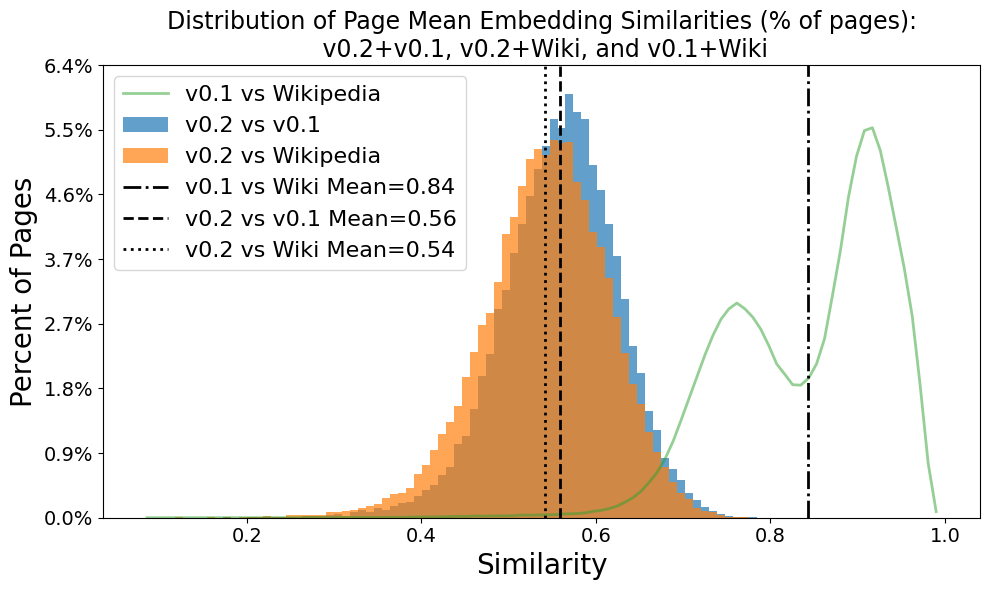

In [701]:
plt.figure(figsize=(10, 6))

# Calculate means for all three distributions
mean_v2_v1 = v2_v1_stats["sim_mean"].mean()
mean_v2_wiki = v2_wiki_stats["sim_mean"].mean()
mean_v1_wiki = v1_wiki_stats['similarity'].mean()

# Histogram bins to ensure all are aligned
all_sims = pd.concat([
    v2_v1_stats['sim_mean'],
    v2_wiki_stats['sim_mean'],
    v1_wiki_stats['similarity']
])
bins = plt.hist(all_sims, bins=100, alpha=0)[1]  # determine common bins

plt.clf()
plt.figure(figsize=(10, 6))

# Plot non-filled line for v0.1 vs Wikipedia (faint)
counts_v1_wiki, bin_edges = np.histogram(
    v1_wiki_stats["similarity"],
    bins=bins,
    density=True
)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
plt.plot(
    bin_centers, counts_v1_wiki,
    color="tab:green",
    linestyle="-",
    linewidth=2,
    alpha=0.5,  # fainter
    label="v0.1 vs Wikipedia"
)

# Plot filled histograms for v0.2 vs v0.1 and v0.2 vs Wikipedia
counts_v2_v1, _, _ = plt.hist(
    v2_v1_stats["sim_mean"],
    bins=bins,
    color="tab:blue",
    label="v0.2 vs v0.1",
    alpha=0.7,
    histtype="stepfilled",
    density=True
)
counts_v2_wiki, _, _ = plt.hist(
    v2_wiki_stats["sim_mean"],
    bins=bins,
    color="tab:orange",
    label="v0.2 vs Wikipedia",
    alpha=0.7,
    histtype="stepfilled",
    density=True
)

# Draw mean lines
plt.axvline(mean_v1_wiki, color="black", linestyle="-.", linewidth=2, label=f"v0.1 vs Wiki Mean={mean_v1_wiki:.2f}")
plt.axvline(mean_v2_v1, color="black", linestyle="--", linewidth=2, label=f"v0.2 vs v0.1 Mean={mean_v2_v1:.2f}")
plt.axvline(mean_v2_wiki, color="black", linestyle=":", linewidth=2, label=f"v0.2 vs Wiki Mean={mean_v2_wiki:.2f}")

# Overlay percent y-axis instead of "density"
ax = plt.gca()
bin_width = bins[1] - bins[0]
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([f"{tick * bin_width * 100:.1f}%" for tick in yticks])

plt.xlabel("Similarity", fontsize=20)
plt.ylabel("Percent of Pages", fontsize=20)
plt.title("Distribution of Page Mean Embedding Similarities (% of pages):\n v0.2+v0.1, v0.2+Wiki, and v0.1+Wiki", fontsize=17)
plt.legend(fontsize=16)
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('../graphics/v02_v01_wiki_similarity_distribution.png', dpi=300)
plt.show()

In [ ]:
v2_v1_t1.sort_values(by='similarity', ascending=False)

,title,v02_chunk_id,v01_chunk_id,similarity
1907016,history of sindh,74,59,1.000000
2633126,list of le corbusier buildings,91,87,1.000000
1936505,hong guk-yeong,11,15,1.000000
4342473,the high denomination bank notes (demonetisati...,85,75,1.000000
2798705,luxury box,97,83,1.000000
...,...,...,...,...
4111867,sssr,9,0,0.006345
4307760,the best things in life are free,42,0,0.004967
4380512,the return of bruno,3,0,0.000385
4307751,the best things in life are free,33,0,-0.006227


In [689]:
v2_wiki_stats.sort_values(by='sim_mean', ascending=False)

,title,n_v02,n_wiki,sim_mean,sim_median,sim_max,sim_p90
6300,caribou (drink),46,1,0.774753,0.772592,0.900998,0.845132
30853,shug monkey,54,1,0.767458,0.779921,0.879573,0.840352
5582,breanna myles,40,2,0.762352,0.774905,0.933857,0.845639
5374,boom symphony,69,1,0.761899,0.759662,0.897456,0.826352
14904,hooyah,64,1,0.759941,0.773828,0.874051,0.832939
...,...,...,...,...,...,...,...
20676,list of shark tank investments,72,1,0.141568,0.142075,0.263159,0.227058
33501,the driftless area,189,4,0.118191,0.081153,0.397351,0.307194
31776,sssr,302,1,0.118062,0.112415,0.308399,0.204089
20055,list of drum manufacturers,120,1,0.100921,0.091994,0.252342,0.157229


In [704]:
v2_wiki_t1[v2_wiki_t1['wiki_chunk_id'] == 0].sort_values(by='similarity', ascending=False)[:50]

,title,v02_chunk_id,wiki_chunk_id,similarity
4065259,surudi milli,0,0,0.969398
2533825,list of heartland episodes,0,0,0.964819
4336172,tony lombardo,0,0,0.962534
3720146,said belqola,0,0,0.960455
150998,2022–23 baylor bears men's basketball team,0,0,0.956461
454225,ashley ellyllon,0,0,0.954986
548767,bashir salihi magashi,0,0,0.954681
3455948,princess elisabeth of thurn and taxis (1860–1881),0,0,0.953914
169607,2023 uab blazers football team,0,0,0.953161
3918809,sofia sapega,0,0,0.953147


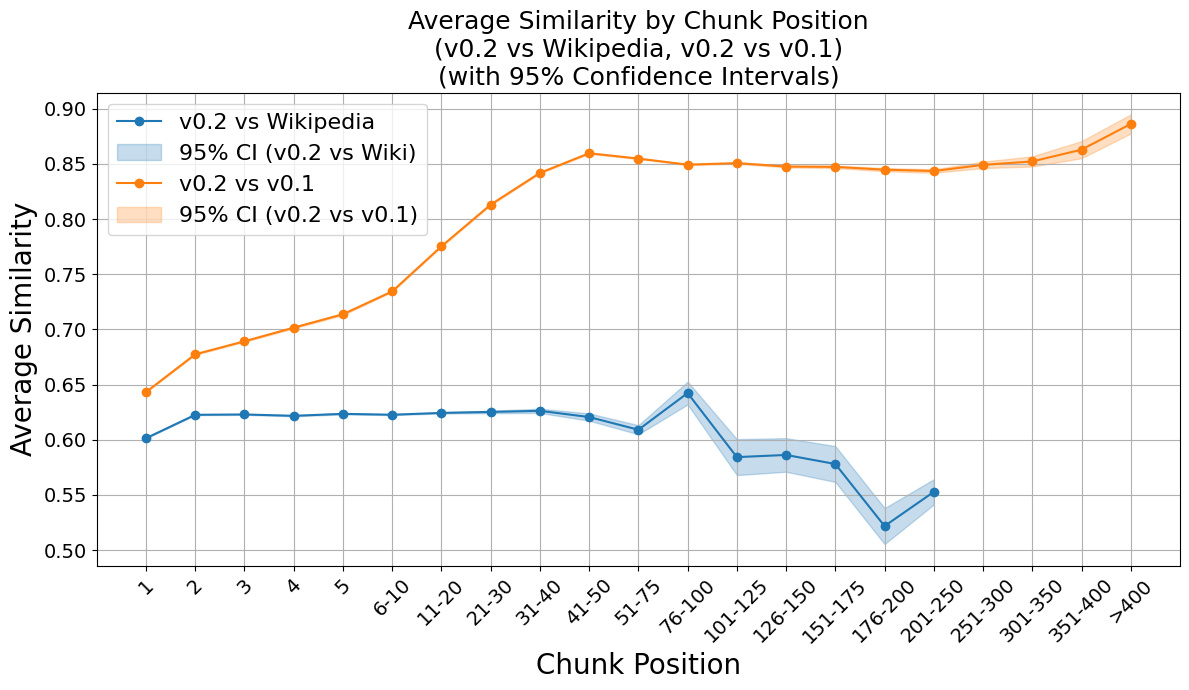

In [706]:
import scipy.stats as stats
import numpy as np

def map_chunk_id_to_bucket(chunk_id):
    if chunk_id == 0:
        return "1"
    elif chunk_id == 1:
        return "2"
    elif chunk_id == 2:
        return "3"
    elif chunk_id == 3:
        return "4"
    elif chunk_id == 4:
        return "5"
    elif chunk_id <= 10:
        return "6-10"
    elif chunk_id <= 20:
        return "11-20"
    elif chunk_id <= 30:
        return "21-30"
    elif chunk_id <= 40:
        return "31-40"
    elif chunk_id <= 50:
        return "41-50"
    elif chunk_id <= 75:
        return "51-75"
    elif chunk_id <= 100:
        return "76-100"
    elif chunk_id <= 125:
        return "101-125"
    elif chunk_id <= 150:
        return "126-150"
    elif chunk_id <= 175:
        return "151-175"
    elif chunk_id <= 200:
        return "176-200"
    elif chunk_id <= 250:
        return "201-250"
    elif chunk_id <= 300:
        return "251-300"
    elif chunk_id <= 350:
        return "301-350"
    elif chunk_id <= 400:
        return "351-400"
    else:
        return ">400"

chunk_bucket_order = [
    "1", "2", "3", "4", "5", "6-10", "11-20", "21-30", "31-40", "41-50",
    "51-75", "76-100", "101-125", "126-150", "151-175", "176-200", "201-250", "251-300",
    "301-350", "351-400", ">400"
]

# ------ v2_wiki_t1: by Wikipedia chunk position
v2_wiki_t1['chunk_bucket'] = v2_wiki_t1['wiki_chunk_id'].apply(map_chunk_id_to_bucket)
grouped_wiki = v2_wiki_t1.groupby('chunk_bucket')["similarity"]
avg_similarity_wiki = grouped_wiki.mean()
count_wiki = grouped_wiki.count()
std_wiki = grouped_wiki.std()

alpha = 0.05
z_score = stats.norm.ppf(1 - alpha/2)
sem_wiki = std_wiki / np.sqrt(count_wiki)
ci_halfwidth_wiki = z_score * sem_wiki

ci_lower_wiki = avg_similarity_wiki - ci_halfwidth_wiki
ci_upper_wiki = avg_similarity_wiki + ci_halfwidth_wiki

plot_df_wiki = pd.DataFrame({
    "mean": avg_similarity_wiki,
    "ci_lower": ci_lower_wiki,
    "ci_upper": ci_upper_wiki
}).reindex(chunk_bucket_order)

# ------ v2_v1_t1: by v0.1 chunk position
v2_v1_t1['chunk_bucket'] = v2_v1_t1['v01_chunk_id'].apply(map_chunk_id_to_bucket)
grouped_v1 = v2_v1_t1.groupby('chunk_bucket')["similarity"]
avg_similarity_v1 = grouped_v1.mean()
count_v1 = grouped_v1.count()
std_v1 = grouped_v1.std()

sem_v1 = std_v1 / np.sqrt(count_v1)
ci_halfwidth_v1 = z_score * sem_v1

ci_lower_v1 = avg_similarity_v1 - ci_halfwidth_v1
ci_upper_v1 = avg_similarity_v1 + ci_halfwidth_v1

plot_df_v1 = pd.DataFrame({
    "mean": avg_similarity_v1,
    "ci_lower": ci_lower_v1,
    "ci_upper": ci_upper_v1
}).reindex(chunk_bucket_order)

x = np.arange(len(chunk_bucket_order))

plt.figure(figsize=(12, 7))
plt.plot(x, plot_df_wiki["mean"], marker='o', label="v0.2 vs Wikipedia", color="tab:blue")
plt.fill_between(
    x,
    plot_df_wiki["ci_lower"],
    plot_df_wiki["ci_upper"],
    color="tab:blue",
    alpha=0.25,
    label="95% CI (v0.2 vs Wiki)"
)
plt.plot(x, plot_df_v1["mean"], marker='o', label="v0.2 vs v0.1", color="tab:orange")
plt.fill_between(
    x,
    plot_df_v1["ci_lower"],
    plot_df_v1["ci_upper"],
    color="tab:orange",
    alpha=0.25,
    label="95% CI (v0.2 vs v0.1)"
)

plt.xlabel('Chunk Position', fontsize=20)
plt.ylabel('Average Similarity', fontsize=20)
plt.title("Average Similarity by Chunk Position\n(v0.2 vs Wikipedia, v0.2 vs v0.1)\n(with 95% Confidence Intervals)", fontsize=18)
plt.xticks(x, chunk_bucket_order, rotation=45, fontsize=14)
plt.grid(True)
plt.legend(fontsize=16)
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.show()

